<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Model_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
from scipy.integrate import odeint

# Custom imports that are either local or pulled from github

Custom imports that are either local or pulled from github

In [90]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

# Imports related to model predictive control and pybounds

In [91]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Set some constant parameters (the blue symbols above)

In [92]:
Lambda = 9.04e-5    #Recuirtment rate per day
mu = 4.3e-5         #Mortility rate per day
gamma = 0.00555     #Removal rate per day

#Dynamic Function

In [93]:
def f(x_vec, u_vec, Lambda=Lambda, mu=mu, gamma=gamma):
    """
    Continuous time dynamics function for the system shown in the equation.

    Parameters:
    x_vec : array-like, shape (6,)
        State vector [S, V, I, R, beta, sigma]
    u_vec : array-like, shape (2,)
        Control vector [alpha, kappa]
    Lambda : float, default 9.04e-5
        recuirtment rate per day
    mu : float, default 3.2e-5
        mortility rate per day
    gamma : float, default
        removal rate per day
    Returns:
    x_dot : numpy array, shape (6,)
        Time derivative of state vector
    """

    # Extract state variables
    S = x_vec[0]
    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]
    beta = x_vec[4]
    sigma = x_vec[5]


    # Extract control inputs
    alpha = u_vec[0]
    kappa = u_vec[1]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ Lambda - beta * S * I - mu * S,
                                 -sigma * beta * V * I - mu * V,
                                 beta*S*I + sigma*beta*V*I - gamma*I - mu*I,
                                 gamma*I - mu*R,
                                 0,
                                 0])

    # f1 component: multiplied by control alpha
    f1_contribution = alpha * np.array([-S,
                                     S,
                                     0,
                                     0,
                                     0,
                                     0])

    # f2 component: multiplied by control kappa
    f2_contribution = kappa * np.array([beta*S*I,
                                     sigma*beta*V*I,
                                     -beta*S*I - sigma*beta*V*I,
                                     0,
                                     0,
                                     0])

    # combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution

    return x_dot_vec

# Make sure dynamics make sense using odeint

Use odeint to perform a simple ODE solver using a simple controller to verify that the dynamics appear to be correct.  

In [94]:
def f_ode(x_vec, tsim, u_func, f):
    '''
    Wrap dynamics function so it can be used with odeint.

    Parameters:
    x_vec : array-like, shape (6,)
        State vector
    tsim : float
        Current time step
    u_func: function
        Control function
    f: function
        Continuous time dynamics function

    Returns:
    x_dot_vec : numpy array, shape (6,)
        Time derivative of state vector
    '''
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)
    return x_dot_vec

In [95]:
def u_func(x_vec, tsim):
    '''
    Controller for vaccination rate (alpha) and vaccine efficacy (kappa).

    Parameters:
    x_vec : array-like, shape (6,)
        Augmented state vector [S, V, I, R, beta, sigma]
    tsim : float
        Current simulation time

    Returns:
    u_vec : list, shape (2,)
        Control vector [alpha, kappa]
    '''
    # Extract infected population
    I = x_vec[2]

    # Simple proportional controller on infected population
    I_des = 0.01  # Desired infected proportion
    err_I = I_des - I

    # Vaccination rate control (alpha) - bounded between 0 and 0.1
    alpha = max(0, min(0.1, 0.5 * err_I))

    # Social distance control (kappa)
    kappa = 0.5

    return [alpha, kappa]

In [96]:
# sim time
dt = 1.0  # 1 day (standard for disease models)
tsim = np.arange(0, 365, step=dt)  # 1 year

#Total population

In [97]:
N = 223000000

In [98]:

x0 = np.array([
    (N - 158330000 - 361000 - 12000000), # S: Recalculate S to close the population gap
    158330000,                            # V: Use the assumed V
    361000,                               # I: Use the assumed I
    12000000,                             # R: Use the assumed R
    0.3,                                  # beta: parameter
    0.8                                   # sigma: parameter
])



In [99]:
# run odeint
result = odeint(f_ode, x0, tsim, args=(u_func, f) )

# DIsease Measurements
$
\mathbf{y} =
\begin{bmatrix}
0.6\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{V}/N
\end{bmatrix}
$

In [100]:
def h(x_vec, u_vec):
    # Extract state variables
    S = x_vec[0]
    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]
    beta = x_vec[4]
    sigma = x_vec[5]

    # Extract control inputs
    alpha = u_vec[0]
    kappa = u_vec[1]

    # Measurements
    y_vec = [0.6*I, V / N]

    # Return measurement
    return y_vec

# Simulate with pybounds / MPC

In [101]:
import pybounds

In [102]:
state_names = ['S', 'V', 'I', 'R', 'beta', 'sigma']
input_names = ['alpha', 'kappa']
measurement_names = ['I_reported', 'V_coverage']

In [103]:
dt = 1

In [104]:
simulator = pybounds.Simulator(f, h, dt=dt, state_names=state_names,
                               input_names=input_names, measurement_names=measurement_names, mpc_horizon=10)

In [105]:
# Define the time horizon
tsim = np.arange(0, 365, step=dt)  # 1 year simulation
NA = np.zeros_like(tsim)

# Control objectives:
# 1. Maximize vaccination coverage (V)
# 2. Minimize infections (I)

# Vaccination setpoint: Ramp up to 80% over the year
V_target = 0.80  # Target 80% vaccination coverage
V_setpoint = np.minimum(V_target * (tsim / 180), V_target)  # Ramp over 180 days

# Infection setpoint: Decrease infections exponentially
I_initial = 361000 / 223000000  # Initial proportion (~0.16%)
I_target = 0.001  # Target 0.1% infected
I_setpoint = I_initial * np.exp(-tsim / 200)  # Exponential decay over 200 days

# Define all setpoints
setpoint = {
    'S': NA,                              # No specific target for susceptible
    'V': V_setpoint,                      # MAXIMIZE: Vaccinated increases to 80%
    'I': I_setpoint,                      # MINIMIZE: Infected decreases exponentially
    'R': NA,                              # No specific target for recovered
    'beta': 0.3 * np.ones_like(tsim),     # Keep parameter estimate constant
    'sigma': 0.8 * np.ones_like(tsim),    # Keep parameter estimate constant
}



In [106]:
# Update the simulator set-point
simulator.update_dict(setpoint, name='setpoint')

In [107]:
# Define MPC cost function: penalize the squared error between the setpoint and the true state
cost_V = (simulator.model.x['V'] - simulator.model.tvp['V_set']) ** 2
cost_I = (simulator.model.x['I'] - simulator.model.tvp['I_set']) ** 2
cost_beta = (simulator.model.x['beta'] - simulator.model.tvp['beta_set']) ** 2
cost_sigma = (simulator.model.x['sigma'] - simulator.model.tvp['sigma_set']) ** 2
cost = 10 * cost_I + 10 * cost_V

In [108]:
simulator.mpc.set_objective(mterm=cost, lterm=cost)

# Set input penalty
simulator.mpc.set_rterm(alpha=1e-4, kappa=1e-4)

In [109]:
simulator.mpc.bounds['lower', '_x', 'S'] = 0.0
simulator.mpc.bounds['upper', '_x', 'S'] = N
simulator.mpc.bounds['lower', '_x', 'V'] = 0.0
simulator.mpc.bounds['upper', '_x', 'V'] = N
simulator.mpc.bounds['lower', '_x', 'I'] = 0.0
simulator.mpc.bounds['upper', '_x', 'I'] = N
simulator.mpc.bounds['lower', '_x', 'R'] = 0.0
simulator.mpc.bounds['upper', '_x', 'R'] = N
simulator.mpc.bounds['lower', '_x', 'beta'] = 0.0
simulator.mpc.bounds['upper', '_x', 'beta'] = 1.0
simulator.mpc.bounds['lower', '_x', 'sigma'] = 0.0
simulator.mpc.bounds['upper', '_x', 'sigma'] = 1.0
simulator.mpc.bounds['lower', '_u', 'alpha'] = 0.0
simulator.mpc.bounds['upper', '_u', 'alpha'] = 0.5
simulator.mpc.bounds['lower', '_u', 'kappa'] = 0.0
simulator.mpc.bounds['upper', '_u', 'kappa'] = 1

In [110]:
# Run simulation using MPC
t_sim, x_sim, u_sim, y_sim = simulator.simulate(x0=None, u=None, mpc=True, return_full_output=True)

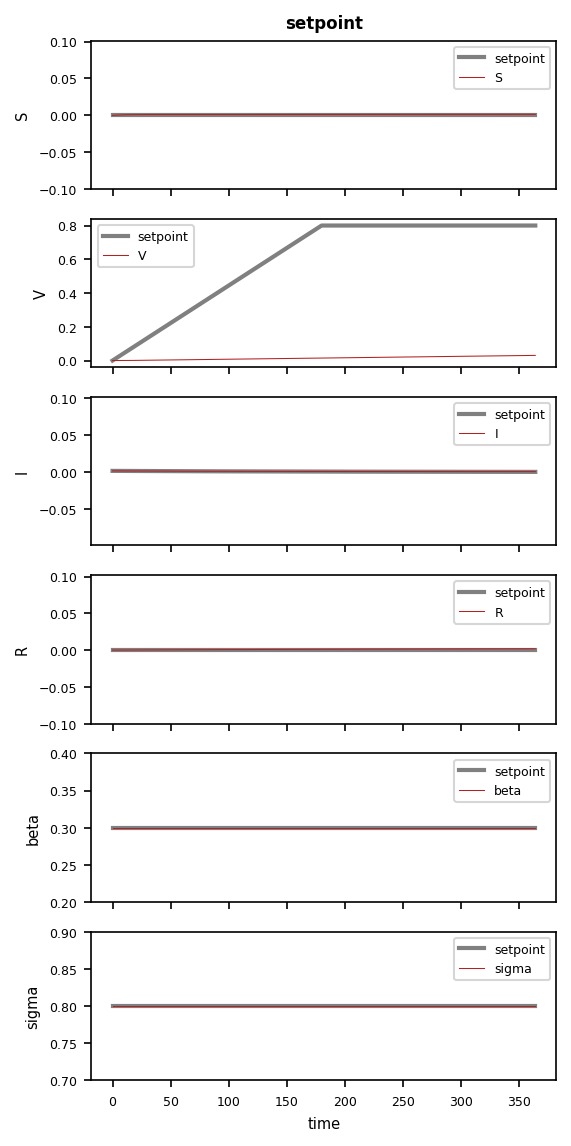

In [111]:
simulator.plot('setpoint')

#Plots

In [112]:
import numpy as np
import matplotlib.pyplot as plt

In [113]:
# Extract states from pybounds output
S_sim = x_sim['S']
V_sim = x_sim['V']
I_sim = x_sim['I']
R_sim = x_sim['R']

In [114]:
# Extract measurements
I_reported_sim = y_sim['I_reported']
V_coverage_sim = y_sim['V_coverage']

#Actual TB Cases vs Reported Cases

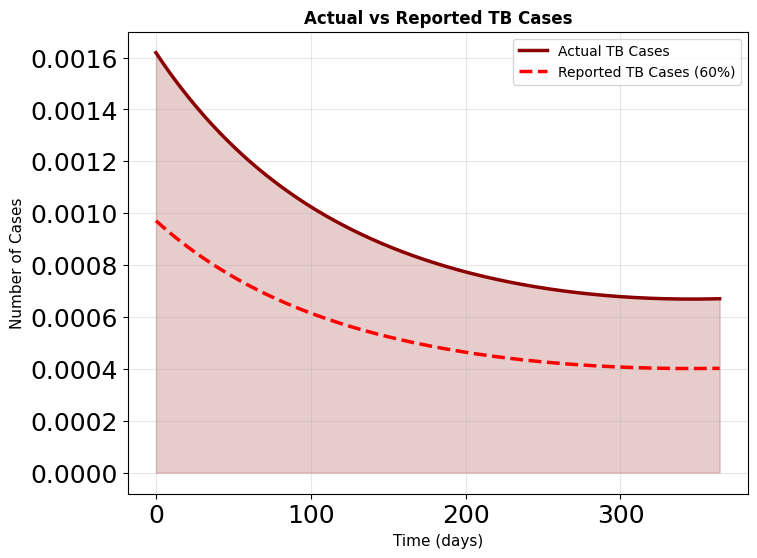

In [115]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(t_sim, I_sim, label='Actual TB Cases', linewidth=2.5, color='darkred')
ax.plot(t_sim, I_reported_sim, label='Reported TB Cases (60%)', linewidth=2.5,
        color='red', linestyle='--')
ax.fill_between(t_sim, I_sim, alpha=0.2, color='darkred')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Number of Cases', fontsize=11)
ax.set_title('Actual vs Reported TB Cases', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

#Disease Spread Over Time (All Compartments)

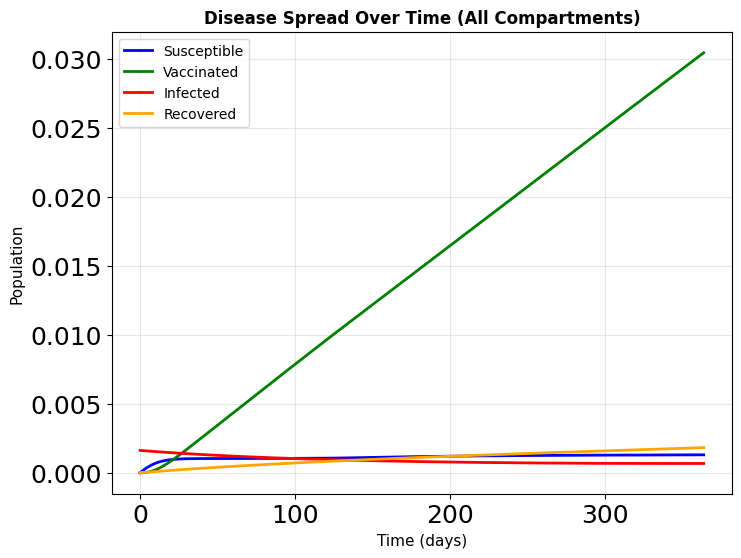

In [116]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(t_sim, S_sim, label='Susceptible', linewidth=2, color='blue')
ax.plot(t_sim, V_sim, label='Vaccinated', linewidth=2, color='green')
ax.plot(t_sim, I_sim, label='Infected', linewidth=2, color='red')
ax.plot(t_sim, R_sim, label='Recovered', linewidth=2, color='orange')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Disease Spread Over Time (All Compartments)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)